# Notebook 3 — A neural sequence?

**Summer course: data-analysis pitfalls**

You have trial-resolved activity from a population of neurons over a 2-second
interval: a `neurons x time x trials` array. A colleague averaged over trials,
found each neuron's peak time, sorted the neurons by peak time, and produced the
figure below.

> ### The claim
> *"These neurons are activated in a reliable, stereotyped temporal **sequence**
> that tiles the whole interval -- each neuron fires at its own characteristic
> moment, one after another."*

Run it and you'll see a beautiful diagonal sweep.

**The claim is not supported by this analysis.** Work out *why*. `hints.md` has
guiding questions, and `notebook3_solution.ipynb` has the answer.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

SMOOTH_SIGMA = 3.0   # temporal smoothing (bins)

def smooth(x):
    return gaussian_filter1d(x, SMOOTH_SIGMA, axis=1)

def zscore_rows(m):
    return (m - m.mean(1, keepdims=True)) / (m.std(1, keepdims=True) + 1e-9)

def show_seq(ax, mat, time, cmap='viridis', title=''):
    n = mat.shape[0]
    im = ax.imshow(zscore_rows(mat), aspect='auto', cmap=cmap,
                   extent=[time[0], time[-1], n, 0])
    ax.set_xlabel('time (s)'); ax.set_ylabel('neuron'); ax.set_title(title)
    return im


In [2]:
d = np.load('data/activity.npz')
activity = d['activity']          # (neuron, time, trial)
time = d['time']; dt = float(d['dt'])
n_neurons, n_time, n_trials = activity.shape
print(f'{n_neurons} neurons x {n_time} time bins x {n_trials} trials '
      f'({time[0]:.2f}-{time[-1]:.2f} s)')


100 neurons x 100 time bins x 10 trials (0.00-1.98 s)


## Step 1 — Trial-average, smooth, and look at the population


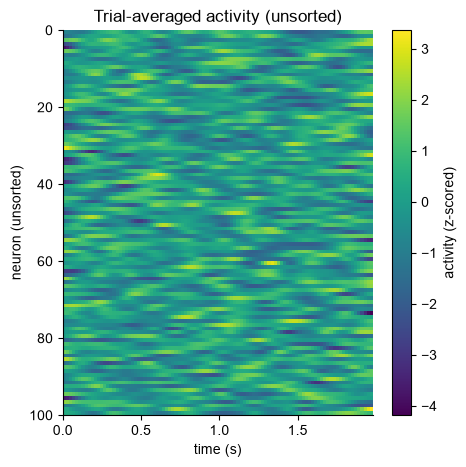

In [3]:
X = activity.mean(axis=2)                 # average over trials -> (neuron, time)
X = smooth(X)                             # smooth each neuron's trace along time

fig, ax = plt.subplots(figsize=(5, 5))
im = show_seq(ax, X, time, title='Trial-averaged activity (unsorted)')
ax.set_ylabel('neuron (unsorted)')
plt.colorbar(im, label='activity (z-scored)')
plt.show()


## Step 2 — Sort neurons by their peak time

Find each neuron's time of peak activity and re-order the population by it.


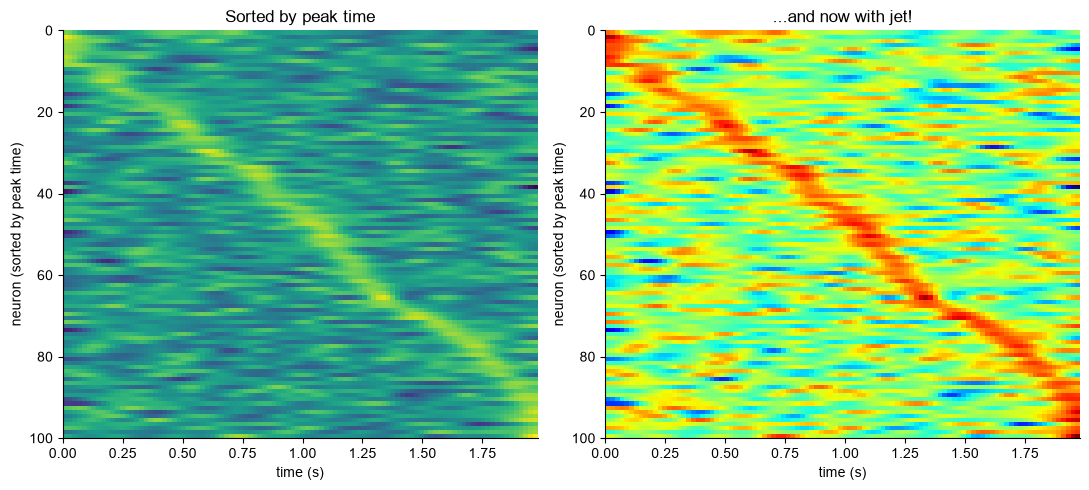

In [4]:
peak_bin = X.argmax(axis=1)      # for each neuron, the time bin of its largest value
order = np.argsort(peak_bin)     # neuron indices ordered from earliest to latest peak

# Re-order the rows of the matrix by that ranking and display it.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
show_seq(axes[0], X[order], time, cmap='viridis', title='Sorted by peak time')
show_seq(axes[1], X[order], time, cmap='jet',     title='...and now with jet!')
for ax in axes:
    ax.set_ylabel('neuron (sorted by peak time)')
plt.tight_layout()
plt.show()


A crisp diagonal: neuron after neuron peaking in turn, spanning the interval.
It looks like a clean sequence -- and the punchy colormap makes it look even
cleaner.
